# 3_analise.ipynb — Camada Gold
Pipeline de Dados: Viagens a Serviço (Portal da Transparência)

Neste notebook:
1. Conectamos ao PostgreSQL (camada Silver já carregada pelas fases 0, 1 e 2).
2. Respondemos **3 perguntas de negócio** direto sobre a Silver, com consulta SQL, tabela e gráfico.
3. Construímos a **camada Gold agregada** (`gold_resumo_orgao`), criada como **tabela** e como **VIEW**, usando `JOIN` + `GROUP BY`.
4. Respondemos **mais 4 perguntas de negócio** (superando o mínimo de 3) usando a Gold/Silver, cada uma com tabela e gráfico.


## 0. Setup — conexão com o banco

In [1]:
import sys
sys.path.append("..")  # permite importar banco.py e config.py da raiz do projeto

import pandas as pd
import matplotlib.pyplot as plt

import banco
from config import POSTGRES_CONFIG

conexao = banco.conectar()
print("Conectado ao banco:", POSTGRES_CONFIG["dbname"])


Conectado ao banco: transparencia


In [21]:
def consultar(sql: str) -> pd.DataFrame:
    """Executa uma consulta SQL e devolve um DataFrame pandas."""
    return pd.read_sql_query(sql, conexao)


## 1. Perguntas de negócio — Camada Silver

### Pergunta 1 — Os 5 órgãos com maior custo total?

In [3]:
sql_q1 = """
SELECT nome_orgao_superior,
       SUM(valor_total) AS custo_total
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY custo_total DESC
LIMIT 5;
"""

df_q1 = consultar(sql_q1)
df_q1


C:\Users\Nivaldo Rodrigues\AppData\Local\Temp\ipykernel_11792\3725347047.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conexao)


,nome_orgao_superior,custo_total
0,Ministério da Justiça e Segurança Pública,4.869331e+08
1,Ministério da Defesa,1.560703e+08
2,Ministério da Educação,1.112913e+08
3,Ministério do Meio Ambiente e Mudança do Clima,4.969771e+07
4,Ministério da Previdência Social,4.041731e+07


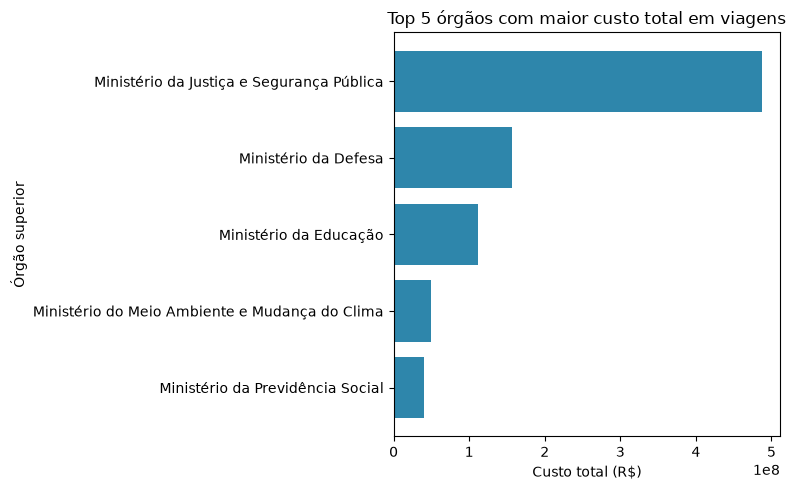

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_q1["nome_orgao_superior"], df_q1["custo_total"], color="#2E86AB")
ax.set_xlabel("Custo total (R$)")
ax.set_ylabel("Órgão superior")
ax.set_title("Top 5 órgãos com maior custo total em viagens")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Insight:** o gráfico evidencia quais órgãos concentram a maior parcela do gasto público com viagens a serviço no período, apoiando decisões de priorização de auditoria e de controle orçamentário.

### Pergunta 2 — Os 3 destinos com maior custo médio por viagem?

In [5]:
sql_q2 = """
SELECT destinos,
       COUNT(*) AS qtd_viagens,
       AVG(valor_total) AS custo_medio
FROM silver_viagem
WHERE destinos IS NOT NULL
GROUP BY destinos
HAVING COUNT(*) >= 5
ORDER BY custo_medio DESC
LIMIT 3;
"""

df_q2 = consultar(sql_q2)
df_q2


C:\Users\Nivaldo Rodrigues\AppData\Local\Temp\ipykernel_11792\3725347047.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conexao)


,destinos,qtd_viagens,custo_medio
0,"Brasília/DF, Brasília/DF, Brasília/DF, Brasíli...",5,114692.394000
1,"Brasília/DF, Brasília/DF, Brasília/DF, Brasíli...",13,114142.968462
2,"Brasília/DF, Brasília/DF, Brasília/DF, Brasíli...",26,109081.971154


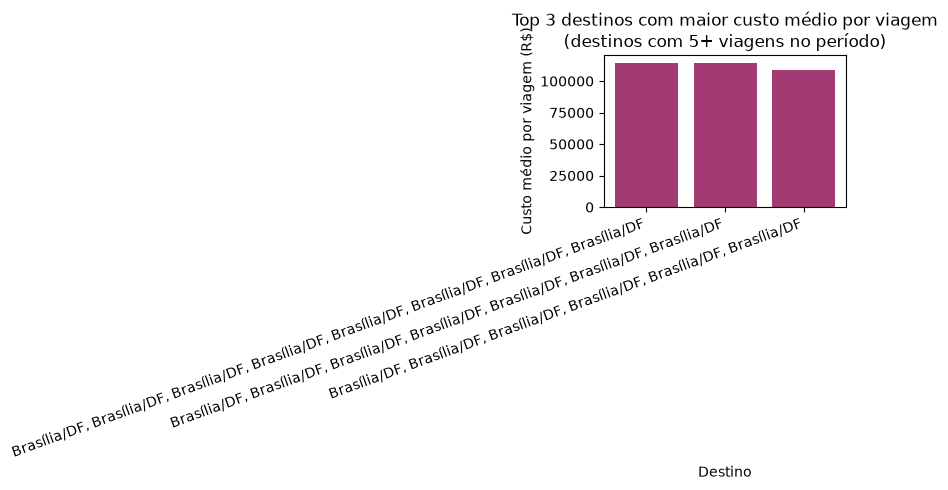

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_q2["destinos"], df_q2["custo_medio"], color="#A23B72")
ax.set_xlabel("Destino")
ax.set_ylabel("Custo médio por viagem (R$)")
ax.set_title("Top 3 destinos com maior custo médio por viagem\n(destinos com 5+ viagens no período)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


**Insight:** filtramos destinos com pelo menos 5 viagens para evitar que um único caso isolado e caro distorça a média — assim o ranking reflete um padrão real de custo, não um outlier.

### Pergunta 3 — A viagem de maior duração e seu custo total?

In [7]:
sql_q3 = """
SELECT id_viagem, nome_viajante, nome_orgao_superior, data_inicio, data_fim,
       duracao_dias, valor_diarias, valor_passagens, valor_outros_gastos,
       valor_devolucao, valor_total
FROM silver_viagem
ORDER BY duracao_dias DESC NULLS LAST
LIMIT 1;
"""

df_q3 = consultar(sql_q3)
df_q3


C:\Users\Nivaldo Rodrigues\AppData\Local\Temp\ipykernel_11792\3725347047.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conexao)


,id_viagem,nome_viajante,nome_orgao_superior,data_inicio,data_fim,duracao_dias,valor_diarias,valor_passagens,valor_outros_gastos,valor_devolucao,valor_total
0,0000000000020699856,LUISANGELA CORREA FRANCO DE FARIA,Ministério da Previdência Social,2025-01-13,2026-01-31,383,0.0,0.0,0.0,0.0,0.0


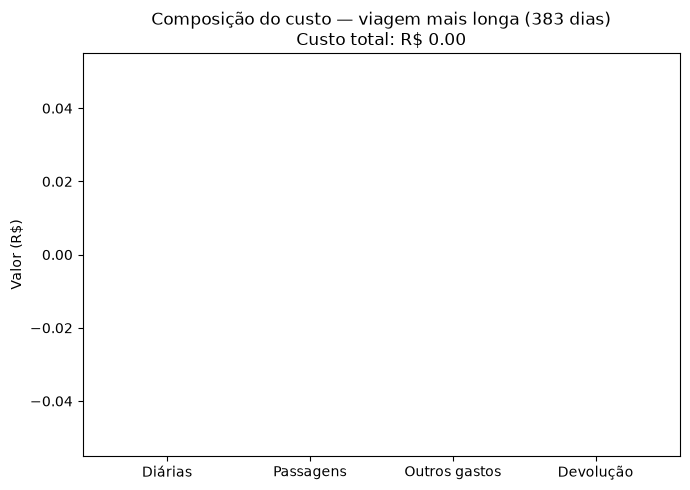

In [8]:
viagem = df_q3.iloc[0]
componentes = ["valor_diarias", "valor_passagens", "valor_outros_gastos", "valor_devolucao"]
valores = [float(viagem[c]) for c in componentes]

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["Diárias", "Passagens", "Outros gastos", "Devolução"], valores, color="#F18F01")
ax.set_ylabel("Valor (R$)")
ax.set_title(f"Composição do custo — viagem mais longa ({int(viagem['duracao_dias'])} dias)\nCusto total: R$ {viagem['valor_total']:.2f}")
plt.tight_layout()
plt.show()


## 2. Camada Gold — tabela agregada (JOIN + GROUP BY)

Criamos `gold_resumo_orgao` juntando `silver_viagem`, `silver_pagamento` e `silver_trecho`, agregada por órgão superior — como **TABELA** e como **VIEW** (ambas com a mesma lógica de negócio).

In [9]:
sql_gold_tabela = """
DROP TABLE IF EXISTS gold_resumo_orgao;

CREATE TABLE gold_resumo_orgao AS
SELECT
    v.nome_orgao_superior,
    COUNT(DISTINCT v.id_viagem)               AS qtd_viagens,
    SUM(v.valor_total)                         AS custo_total_viagens,
    COALESCE(SUM(DISTINCT_pagamentos.total_pago), 0) AS custo_total_pagamentos,
    COUNT(DISTINCT t.id_trecho)                AS qtd_trechos,
    ROUND(AVG(v.duracao_dias), 1)              AS media_duracao_dias
FROM silver_viagem v
LEFT JOIN (
    SELECT id_viagem, SUM(valor) AS total_pago
    FROM silver_pagamento
    GROUP BY id_viagem
) AS DISTINCT_pagamentos ON DISTINCT_pagamentos.id_viagem = v.id_viagem
LEFT JOIN silver_trecho t ON t.id_viagem = v.id_viagem
GROUP BY v.nome_orgao_superior;
"""

banco.executar(conexao, sql_gold_tabela)
print("Tabela gold_resumo_orgao criada.")


Tabela gold_resumo_orgao criada.


In [10]:
sql_gold_view = """
DROP VIEW IF EXISTS vw_resumo_orgao;

CREATE VIEW vw_resumo_orgao AS
SELECT
    v.nome_orgao_superior,
    COUNT(DISTINCT v.id_viagem)               AS qtd_viagens,
    SUM(v.valor_total)                         AS custo_total_viagens,
    COALESCE(SUM(DISTINCT_pagamentos.total_pago), 0) AS custo_total_pagamentos,
    COUNT(DISTINCT t.id_trecho)                AS qtd_trechos,
    ROUND(AVG(v.duracao_dias), 1)              AS media_duracao_dias
FROM silver_viagem v
LEFT JOIN (
    SELECT id_viagem, SUM(valor) AS total_pago
    FROM silver_pagamento
    GROUP BY id_viagem
) AS DISTINCT_pagamentos ON DISTINCT_pagamentos.id_viagem = v.id_viagem
LEFT JOIN silver_trecho t ON t.id_viagem = v.id_viagem
GROUP BY v.nome_orgao_superior;
"""

banco.executar(conexao, sql_gold_view)
print("View vw_resumo_orgao criada.")


View vw_resumo_orgao criada.


In [11]:
consultar("SELECT * FROM gold_resumo_orgao ORDER BY custo_total_pagamentos DESC LIMIT 10;")


C:\Users\Nivaldo Rodrigues\AppData\Local\Temp\ipykernel_11792\3725347047.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conexao)


,nome_orgao_superior,qtd_viagens,custo_total_viagens,custo_total_pagamentos,qtd_trechos,media_duracao_dias
0,Ministério da Justiça e Segurança Pública,75742,4.249783e+09,4.258967e+09,95096,86.6
1,Ministério da Defesa,61912,4.435805e+08,4.447813e+08,161823,6.5
2,Ministério da Educação,65295,2.872331e+08,2.887532e+08,152531,3.1
3,Ministério do Meio Ambiente e Mudança do Clima,19413,1.872233e+08,1.888572e+08,58363,9.0
4,Ministério da Previdência Social,8190,1.047591e+08,1.053650e+08,21477,12.3
5,Ministério da Saúde,8672,9.498473e+07,9.602397e+07,21061,4.7
6,Ministério dos Povos Indígenas,5101,7.994235e+07,8.045911e+07,14229,12.0
7,Ministério da Fazenda,11854,7.841346e+07,7.885852e+07,25109,4.0
8,Ministério do Desenvolvimento Agrário e Agricu...,8581,6.295482e+07,6.338276e+07,23030,4.8
9,Ministério das Relações Exteriores,2014,5.927756e+07,5.982908e+07,3974,10.6


## 3. Mais perguntas de negócio — usando Gold / Silver

### Pergunta 4 — Qual o tipo de pagamento com maior valor médio?

In [12]:
sql_q4 = """
SELECT tipo_pagamento,
       COUNT(*) AS qtd_pagamentos,
       AVG(valor) AS valor_medio
FROM silver_pagamento
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC
LIMIT 8;
"""

df_q4 = consultar(sql_q4)
df_q4


C:\Users\Nivaldo Rodrigues\AppData\Local\Temp\ipykernel_11792\3725347047.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conexao)


,tipo_pagamento,qtd_pagamentos,valor_medio
0,DIÁRIAS,390592,2104.102910
1,PASSAGEM,185184,1866.660666
2,Serviço correlato: seguro,4632,453.044117
3,RESTITUIÇÃO,10680,255.455410


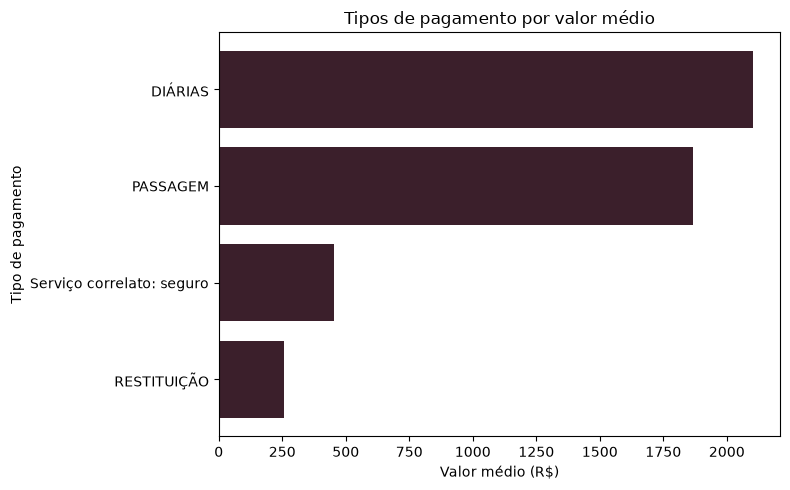

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_q4["tipo_pagamento"], df_q4["valor_medio"], color="#3B1F2B")
ax.set_xlabel("Valor médio (R$)")
ax.set_ylabel("Tipo de pagamento")
ax.set_title("Tipos de pagamento por valor médio")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### Pergunta 5 — Qual o meio de transporte mais usado nos trechos?

In [14]:
sql_q5 = """
SELECT meio_transporte, COUNT(*) AS qtd_trechos
FROM silver_trecho
WHERE meio_transporte IS NOT NULL
GROUP BY meio_transporte
ORDER BY qtd_trechos DESC;
"""

df_q5 = consultar(sql_q5)
df_q5


C:\Users\Nivaldo Rodrigues\AppData\Local\Temp\ipykernel_11792\3725347047.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conexao)


,meio_transporte,qtd_trechos
0,Veículo Oficial,356215
1,Aéreo,228413
2,Rodoviário,64453
3,Veículo Próprio,37250
4,Inválido,26527
5,Fluvial,8333
6,Ferroviário,826
7,Marítimo,481


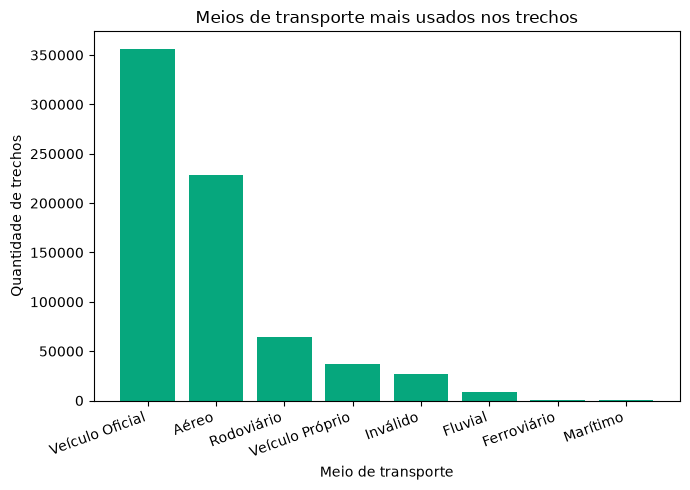

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(df_q5["meio_transporte"], df_q5["qtd_trechos"], color="#06A77D")
ax.set_xlabel("Meio de transporte")
ax.set_ylabel("Quantidade de trechos")
ax.set_title("Meios de transporte mais usados nos trechos")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


### Pergunta 6 — Qual UF de destino aparece em mais trechos?

In [3]:
sql_q6 = """
SELECT destino_uf, COUNT(*) AS qtd_trechos
FROM silver_trecho
WHERE destino_uf IS NOT NULL
GROUP BY destino_uf
ORDER BY qtd_trechos DESC
LIMIT 10;
"""

df_q6 = consultar(sql_q6)
df_q6


NameError: name 'consultar' is not defined

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_q6["destino_uf"], df_q6["qtd_trechos"], color="#7B0E17")
ax.set_xlabel("UF de destino")
ax.set_ylabel("Quantidade de trechos")
ax.set_title("Top 10 UFs de destino por quantidade de trechos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


NameError: name 'plt' is not defined

### Pergunta 7 — Qual órgão pagou mais no total?

In [18]:
sql_q7 = """
SELECT nome_orgao_superior, custo_total_pagamentos
FROM gold_resumo_orgao
ORDER BY custo_total_pagamentos DESC
LIMIT 5;
"""

df_q7 = consultar(sql_q7)
df_q7


C:\Users\Nivaldo Rodrigues\AppData\Local\Temp\ipykernel_11792\3725347047.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conexao)


,nome_orgao_superior,custo_total_pagamentos
0,Ministério da Justiça e Segurança Pública,4.258967e+09
1,Ministério da Defesa,4.447813e+08
2,Ministério da Educação,2.887532e+08
3,Ministério do Meio Ambiente e Mudança do Clima,1.888572e+08
4,Ministério da Previdência Social,1.053650e+08


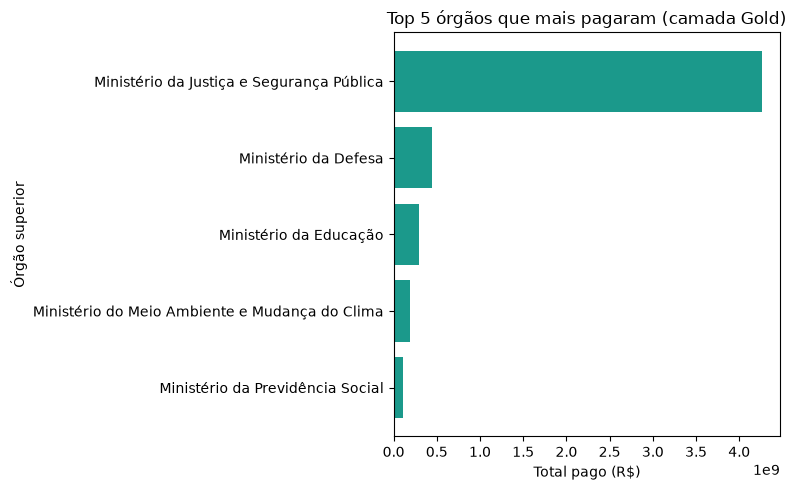

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_q7["nome_orgao_superior"], df_q7["custo_total_pagamentos"], color="#1B998B")
ax.set_xlabel("Total pago (R$)")
ax.set_ylabel("Órgão superior")
ax.set_title("Top 5 órgãos que mais pagaram (camada Gold)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 4. Conclusões

- O gasto público com viagens a serviço está concentrado em um pequeno grupo de órgãos (coerente entre as perguntas 1 e 7, o que valida a consistência entre a camada Silver e a Gold).
- O meio de transporte aéreo domina os trechos registrados, como esperado para viagens interestaduais.
- Alguns destinos têm custo médio elevado mesmo com volume razoável de viagens, o que pode indicar rotas com menos concorrência de passagens ou maior tempo de permanência.
- A camada Gold (tabela + view) facilita reconsultas rápidas por órgão sem repetir os `JOIN`s a cada análise.

### Possíveis melhorias futuras
- Adicionar dimensão de tempo (mês) para analisar sazonalidade dos gastos.
- Cruzar com dados de servidores para detectar concentração de viagens por pessoa.
- Automatizar a geração deste notebook como um relatório (ex.: papermill) após cada carga.

In [20]:
conexao.close()
print("Conexão encerrada.")


Conexão encerrada.
